## Google Earth Engine with geemap 

This notebook will demostrate how to access Google Earth Engine from python through the `ee` and `geemap` packages.

`geemap`: is a Python package for interactive geospatial analysis and visualization with Google Earth Engine

Below are the examples provided in this notebook.
- A quick start of geemap
- Zonal Statistics with Polygon GIS file
- Generate time series animation

## Installation

In [1]:

#pip install geemap

## Quick start and demo

In [2]:
import ee
import geemap

In [3]:
Map = geemap.Map()

In [4]:
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [5]:
Map = geemap.Map(center=(40, -100), zoom=4)

In [6]:
Map

Map(center=[40, -100], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

You may need to run this if your map is not shown

In [7]:
#conda install -c conda-forge ipyleaflet #https://ipyleaflet.readthedocs.io/en/latest/installation/index.html

You can add some more basemap layers, and below are all the options

Basemap can only be one of the following:
  OpenStreetMap
  Esri.WorldStreetMap
  Esri.WorldImagery
  Esri.WorldTopoMap
  FWS NWI Wetlands
  FWS NWI Wetlands Raster
  NLCD 2021 CONUS Land Cover
  NLCD 2019 CONUS Land Cover
  NLCD 2016 CONUS Land Cover
  NLCD 2013 CONUS Land Cover
  NLCD 2011 CONUS Land Cover
  NLCD 2008 CONUS Land Cover
  NLCD 2006 CONUS Land Cover
  NLCD 2004 CONUS Land Cover
  NLCD 2001 CONUS Land Cover
  USGS NAIP Imagery
  USGS NAIP Imagery False Color
  USGS NAIP Imagery NDVI
  USGS Hydrography
  USGS 3DEP Elevation
  ESA Worldcover 2020
  ESA Worldcover 2020 S2 FCC
  ESA Worldcover 2020 S2 TCC
  ESA Worldcover 2021
  ESA Worldcover 2021 S2 FCC
  ESA Worldcover 2021 S2 TCC
  BasemapAT.basemap
  BasemapAT.grau
  BasemapAT.highdpi
  BasemapAT.orthofoto
  BasemapAT.overlay
  BasemapAT.surface
  BasemapAT.terrain
  CartoDB.DarkMatter
  CartoDB.DarkMatterNoLabels
  CartoDB.DarkMatterOnlyLabels
  CartoDB.Positron
  CartoDB.PositronNoLabels
  CartoDB.PositronOnlyLabels
  CartoDB.Voyager
  CartoDB.VoyagerLabelsUnder
  CartoDB.VoyagerNoLabels
  CartoDB.VoyagerOnlyLabels
  CyclOSM
  Esri.AntarcticBasemap
  Esri.AntarcticImagery
  Esri.ArcticImagery
  Esri.ArcticOceanBase
  Esri.ArcticOceanReference
  Esri.DeLorme
  Esri.NatGeoWorldMap
  Esri.OceanBasemap
  Esri.WorldGrayCanvas
  Esri.WorldPhysical
  Esri.WorldShadedRelief
  Esri.WorldTerrain
  FreeMapSK
  Gaode.Normal
  Gaode.Satellite
  HikeBike.HikeBike
  HikeBike.HillShading
  JusticeMap.americanIndian
  JusticeMap.asian
  JusticeMap.black
  JusticeMap.hispanic
  JusticeMap.income
  JusticeMap.multi
  JusticeMap.nonWhite
  JusticeMap.plurality
  JusticeMap.white
  MtbMap
  NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief
  NASAGIBS.BlueMarble
  NASAGIBS.BlueMarble3031
  NASAGIBS.BlueMarble3413
  NASAGIBS.ModisAquaBands721CR
  NASAGIBS.ModisAquaTrueColorCR
  NASAGIBS.ModisTerraAOD
  NASAGIBS.ModisTerraBands367CR
  NASAGIBS.ModisTerraBands721CR
  NASAGIBS.ModisTerraChlorophyll
  NASAGIBS.ModisTerraLSTDay
  NASAGIBS.ModisTerraSnowCover
  NASAGIBS.ModisTerraTrueColorCR
  NASAGIBS.ViirsEarthAtNight2012
  NASAGIBS.ViirsTrueColorCR
  NLS
  OPNVKarte
  OneMapSG.Default
  OneMapSG.Grey
  OneMapSG.LandLot
  OneMapSG.Night
  OneMapSG.Original
  OpenAIP
  OpenFireMap
  OpenRailwayMap
  OpenSeaMap
  OpenSnowMap.pistes
  OpenStreetMap.BZH
  OpenStreetMap.BlackAndWhite
  OpenStreetMap.CH
  OpenStreetMap.DE
  OpenStreetMap.HOT
  OpenStreetMap.Mapnik
  OpenTopoMap
  SafeCast
  Stadia.AlidadeSmooth
  Stadia.AlidadeSmoothDark
  Stadia.OSMBright
  Stadia.Outdoors
  Stamen.Terrain
  Stamen.TerrainBackground
  Stamen.TerrainLabels
  Stamen.Toner
  Stamen.TonerBackground
  Stamen.TonerHybrid
  Stamen.TonerLabels
  Stamen.TonerLines
  Stamen.TonerLite
  Stamen.TopOSMFeatures
  Stamen.TopOSMRelief
  Stamen.Watercolor
  Strava.All
  Strava.Ride
  Strava.Run
  Strava.Water
  Strava.Winter
  SwissFederalGeoportal.JourneyThroughTime
  SwissFederalGeoportal.NationalMapColor
  SwissFederalGeoportal.NationalMapGrey
  SwissFederalGeoportal.SWISSIMAGE
  USGS.USImagery
  USGS.USImageryTopo
  USGS.USTopo
  WaymarkedTrails.cycling
  WaymarkedTrails.hiking
  WaymarkedTrails.mtb
  WaymarkedTrails.riding
  WaymarkedTrails.skating
  WaymarkedTrails.slopes
  nlmaps.grijs
  nlmaps.luchtfoto
  nlmaps.pastel
  nlmaps.standaard
  nlmaps.water

In [8]:
Map = geemap.Map()

Map.add_basemap("CartoDB.DarkMatter")

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

### Adding image dataset

All available datasets are: https://developers.google.com/earth-engine/datasets/

Add a DEM data

In [9]:
dataset = ee.Image('USGS/3DEP/10m')
elevation = dataset.select('elevation')

#slope = ee.Terrain.slope(elevation)

Map.setCenter(-112.8598, 36.2841, 10)


Map.addLayer(elevation, {"min": 0, "max": 3000,   "palette": ['000000','ffffff'
  ],
                         
}, 'elevation_layer')


#Map.addLayer(slope, {min: 0, max: 60}, 'slope')


In [10]:
dataset = ee.Image('USGS/3DEP/10m')
elevation = dataset.select('elevation')


viz = {'min': 0, 
       'max': 3000,
       'palette': ['000000','ffffff'], #scale the min and max based on the palette
}


Map.addLayer(elevation, viz , 'elevation');

Map

Map(center=[36.2841, -112.8598], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

## Land cover data

In [11]:
dataset = ee.ImageCollection('ESA/WorldCover/v200').first()

visualization = {
  "bands": ['Map'],
}

Map.centerObject(dataset)

Map.addLayer(dataset, visualization, 'Landcover')

In [12]:
Map

Map(center=[36.2841, -112.8598], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [13]:
landcover = ee.ImageCollection('ESA/WorldCover/v200').first()

visualization = {
  'bands': ['Map'],
}


Map.addLayer(landcover, visualization, 'Landcover')


#Map land cover class = 10
Map.addLayer(landcover.eq(10), {}, 'forest')

In [14]:
Map

Map(center=[0.0, 0.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [15]:
states = ee.FeatureCollection("TIGER/2018/States")
Map.addLayer(states, {}, "US States")

In [16]:
counties = ee.FeatureCollection("TIGER/2018/Counties")

In [17]:
Map.addLayer(counties, {}, 'counties_layer')

## Zonal Statistics


![Image of Zonal stats](http://www.geography.hunter.cuny.edu/~jochen/GTECH361/lectures/lecture11/concepts/Zonal%20Statistics_files/image002.gif)




### Task: Calcualte highest elevation point for each county in FL

In [18]:
import geopandas as gpd

In [19]:
# Load your GIS file as a GeoDataFrame
path = "https://raw.githubusercontent.com/Ziqi-Li/GIS5103/main/data/fl_income.geojson"

gdf = gpd.read_file(path)

<Axes: >

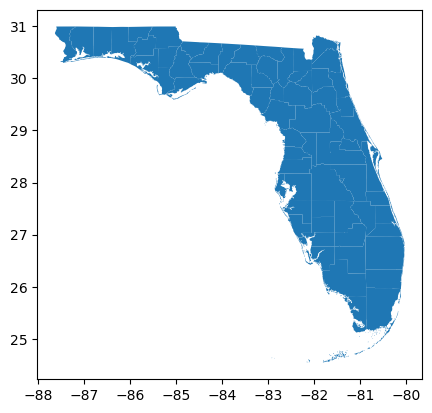

In [20]:
gdf.plot()

In [21]:
# Convert the GeoDataFrame to an Earth Engine feature collection
features = geemap.geopandas_to_ee(gdf)

Possible Zonal Statistics keywords:

COUNT, MEAN, MEAN_UNWEIGHTED, MAXIMUM, MEDIAN, MINIMUM, MODE, STD, MIN_MAX, SUM, VARIANCE, HIST, FIXED_HIST, COMBINED_COUNT_MEAN, COMBINED_COUNT_MEAN_UNWEIGHTED

In [22]:
geemap.zonal_stats(elevation, features, "result.geojson", 
                   stat_type="MAXIMUM")

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/ziqili/Desktop/GIS Coding/result.geojson


In [23]:
result = gpd.read_file("result.geojson")

In [24]:
result.head()

,id,max,COUNTY,COUNTYNAME,Geo_ID,Median_income,Name,geometry
0,0,35.284779,041,GILCHRIST,0500000US12041,50983,"Gilchrist County, Florida","POLYGON ((-82.658 29.83, -82.659 29.83, -82.66..."
1,1,68.072441,107,PUTNAM,0500000US12107,39975,"Putnam County, Florida","POLYGON ((-81.581 29.84, -81.606 29.84, -81.62..."
2,2,31.549129,123,TAYLOR,0500000US12123,43563,"Taylor County, Florida","MULTIPOLYGON (((-83.73 30.304, -83.74 30.303, ..."
3,3,96.228264,091,OKALOOSA,0500000US12091,67390,"Okaloosa County, Florida","MULTIPOLYGON (((-86.392 30.65, -86.392 30.652,..."
4,4,82.574677,013,CALHOUN,0500000US12013,38098,"Calhoun County, Florida","POLYGON ((-84.933 30.606, -84.957 30.606, -84...."


Text(0.5, 1.0, 'The highest elevation in each county')

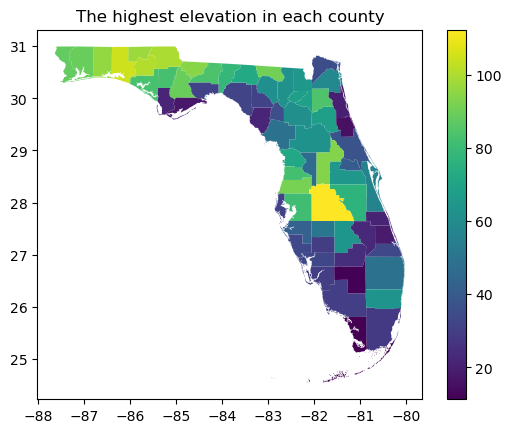

In [25]:
import matplotlib.pyplot as plt

result.plot("max",legend=True)

plt.title("The highest elevation in each county")

Calcualte percentage of forest cover in each county


Count total number of forest pixels per county.

Note that you can use `.mask` to mask out pixels based on a certain math condition, in this example `=10`.

In [26]:
geemap.zonal_stats(landcover.mask(landcover.eq(10)), features, 
                   "land_cover_forest_result.geojson", stat_type="COUNT")

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/ziqili/Desktop/GIS Coding/land_cover_forest_result.geojson


Get total number of pixels per county

In [27]:
geemap.zonal_stats(landcover, features, "land_cover_all_result.geojson", stat_type="COUNT")

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/ziqili/Desktop/GIS Coding/land_cover_all_result.geojson


In [28]:
forest = gpd.read_file("land_cover_forest_result.geojson")

all_type = gpd.read_file("land_cover_all_result.geojson")

In [29]:
all_type

,id,count,COUNTY,COUNTYNAME,Geo_ID,Median_income,Name,geometry
0,0,123598,041,GILCHRIST,0500000US12041,50983,"Gilchrist County, Florida","POLYGON ((-82.658 29.83, -82.659 29.83, -82.66..."
1,1,287322,107,PUTNAM,0500000US12107,39975,"Putnam County, Florida","POLYGON ((-81.581 29.84, -81.606 29.84, -81.62..."
2,2,361741,123,TAYLOR,0500000US12123,43563,"Taylor County, Florida","MULTIPOLYGON (((-83.73 30.304, -83.74 30.303, ..."
3,3,321246,091,OKALOOSA,0500000US12091,67390,"Okaloosa County, Florida","MULTIPOLYGON (((-86.392 30.65, -86.392 30.652,..."
4,4,201033,013,CALHOUN,0500000US12013,38098,"Calhoun County, Florida","POLYGON ((-84.933 30.606, -84.957 30.606, -84...."
...,...,...,...,...,...,...,...,...
62,62,239577,033,ESCAMBIA,0500000US12033,56605,"Escambia County, Florida","MULTIPOLYGON (((-87.231 30.997, -87.238 30.997..."
63,63,303113,093,OKEECHOBEE,0500000US12093,47020,"Okeechobee County, Florida","POLYGON ((-80.679 27.558, -80.679 27.558, -80...."
64,64,194418,037,FRANKLIN,0500000US12037,52679,"Franklin County, Florida","MULTIPOLYGON (((-84.667 30.012, -84.71 30.012,..."
65,65,336987,001,ALACHUA,0500000US12001,53314,"Alachua County, Florida","POLYGON ((-82.419 29.923, -82.419 29.923, -82...."


Simple math to calculate the forest share per county.

In [30]:
forest["perc_forest"] = forest["count"]/all_type["count"] * 100

Text(0.5, 1.0, '% of Forest Cover')

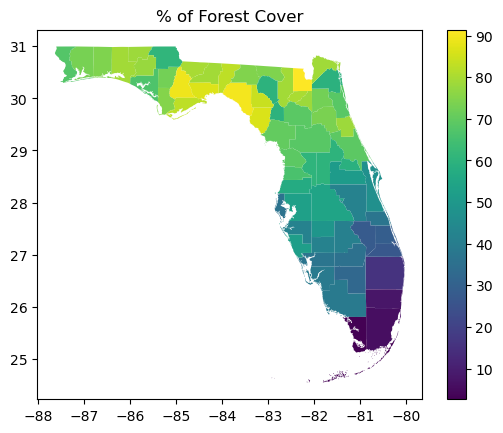

In [31]:
forest.plot(column="perc_forest", legend=True)
plt.title("% of Forest Cover")

## Animation

In [32]:
import ee
import geemap

# Define an area of interest geometry with a global non-polar extent.
#Global
aoi = ee.Geometry.Polygon(
  [[[-179.0, 78.0], [-179.0, -58.0], [179.0, -58.0], [179.0, 78.0]]], None, False)


# Import hourly predicted temperature image collection for northern winter
# solstice. Note that predictions extend for 384 hours; limit the collection
# to the first 24 hours.

era5_2mt = (
    ee.ImageCollection('ECMWF/ERA5/DAILY')
    .select('mean_2m_air_temperature')
    .filter(ee.Filter.date('2019-07-01', '2019-08-01'))
)


# Define arguments for animation function parameters.
videoArgs = {
  'dimensions': 768,
  'region': aoi,
  'framesPerSecond': 10,
  'crs': 'EPSG:3857',
    'min': 250,
    'max': 320,
    'palette': [
        '000080',
        '0000d9',
        '4000ff',
        '8000ff',
        '0080ff',
        '00ffff',
        '00ff80',
        '80ff00',
        'daff00',
        'ffff00',
        'fff500',
        'ffda00',
        'ffb000',
        'ffa400',
        'ff4f00',
        'ff2500',
        'ff0a00',
        'ff00ff',
    ],
}


In [33]:
#Submit the request to GEE and download it.
import os

geemap.download_ee_video(era5_2mt, videoArgs, 'temperature.gif')

Generating URL...
Please wait ...
The GIF image has been saved to: /Users/ziqili/Desktop/GIS Coding/temperature.gif


In [34]:
geemap.show_image('temperature.gif')

Output()

In [35]:
#Add some text to the video showing the hour of temperature measured.
text = ["July " + str(n+1) for n in range(0, 31)]

print(text)

['July 1', 'July 2', 'July 3', 'July 4', 'July 5', 'July 6', 'July 7', 'July 8', 'July 9', 'July 10', 'July 11', 'July 12', 'July 13', 'July 14', 'July 15', 'July 16', 'July 17', 'July 18', 'July 19', 'July 20', 'July 21', 'July 22', 'July 23', 'July 24', 'July 25', 'July 26', 'July 27', 'July 28', 'July 29', 'July 30', 'July 31']


In [36]:
geemap.add_text_to_gif('temperature.gif', 'temperature.gif', xy=('3%', '5%'), 
                       text_sequence=text, font_size=30, font_color='#000000')

geemap.show_image('temperature.gif')

Output()

A Landsat time series

In [37]:
#Define a study area
roi_tlh = ee.Geometry.Polygon(
    [[[-84.4365, 30.3482],
      [-84.4365, 30.5498],
      [-84.1531, 30.5498],
      [-84.1531, 30.3482]]],
    None,
    False,)


In [38]:
collection = geemap.landsat_timeseries(roi=roi_tlh, start_year=1990, end_year=2020)

In [39]:
#Some video parameters
# Define arguments for animation function parameters.
video_args = {
  'dimensions': 768,
  'region': roi_tlh,
  'bands': ['Red', 'Green', 'Blue'],
  'min': 0,
  'max': 0.1,
}

In [40]:
geemap.download_ee_video(collection, video_args, "tlh_land_cover.gif")

Generating URL...
Please wait ...
The GIF image has been saved to: /Users/ziqili/Desktop/GIS Coding/tlh_land_cover.gif


In [41]:
geemap.show_image("tlh_land_cover.gif")

Output()

In [42]:
geemap.add_text_to_gif("tlh_land_cover.gif", "tlh_land_cover.gif", xy=('3%', '5%'), 
                       text_sequence=1990, font_size=30, font_color='#ffffff', add_progress_bar=False)

In [43]:
geemap.show_image("tlh_land_cover.gif")

Output()